<a href="https://colab.research.google.com/github/TegarReskiPratama/Analisis-Perbandingan-Kinerja-Model-Transformer-IndoBERT-IndoBERTweet-dan-XLM-RoBERTa-/blob/main/Analisis_Perbandingan_Kinerja_Model_Transformer_IndoBERT%2C_IndoBERTweet%2C_dan_XLM_RoBERTa_dalam_Deteksi_Promosi_Judi_Online_Berbahasa_Indonesia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q transformers datasets accelerate evaluate
!pip install -q sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df1 = pd.read_csv("youtube_chat_jogja_clean.csv")
df2 = pd.read_csv("data_komentar_dengan_prediksi - data_komentar_dengan_prediksi(2).csv")

print(df1.shape)
print(df2.shape)

(6350, 5)
(10230, 9)


# Ambil Kolom yang Digunakan

In [ ]:
df1 = df1[['cleaned_message','label']]
df1.columns = ['text','label']

df2 = df2[['komentar_clean','label']]
df2.columns = ['text','label']

print(df1.head())
print(df2.head())

                                                text  label
0                                    assalamualaikum      0
1                                   waalaikumussalam      0
2                             udah lewat 22 menit ni      0
3                                           1630 wib      0
4  tribun tv mana ini kenapa acaranya belum dimul...      0
                                                text  label
0  makin yakin abis baca review lain tentang 𝐒𝐆𝐈𝟖𝟖 .      1
1                                      suka model h2      0
2                               mobilnya udah hancur      0
3                       ░𝙈𝘼𝙉𝙐𝙏88░benar2 bikin sultan      1
4             semoga lekas recover mobilnya mas dipo      0


In [ ]:
df = pd.concat([df1,df2], ignore_index=True)

print("Jumlah Data:", len(df))
df.head()

Jumlah Data: 16580


,text,label
0,assalamualaikum,0
1,waalaikumussalam,0
2,udah lewat 22 menit ni,0
3,1630 wib,0
4,tribun tv mana ini kenapa acaranya belum dimul...,0


# Cleaning

In [ ]:
df.dropna(inplace=True)

df['text'] = df['text'].astype(str)

df = df[df['text'].str.len() > 3]

df.drop_duplicates(inplace=True)

df.reset_index(drop=True, inplace=True)

print(df.shape)

(11491, 2)


# WordCloud Judol

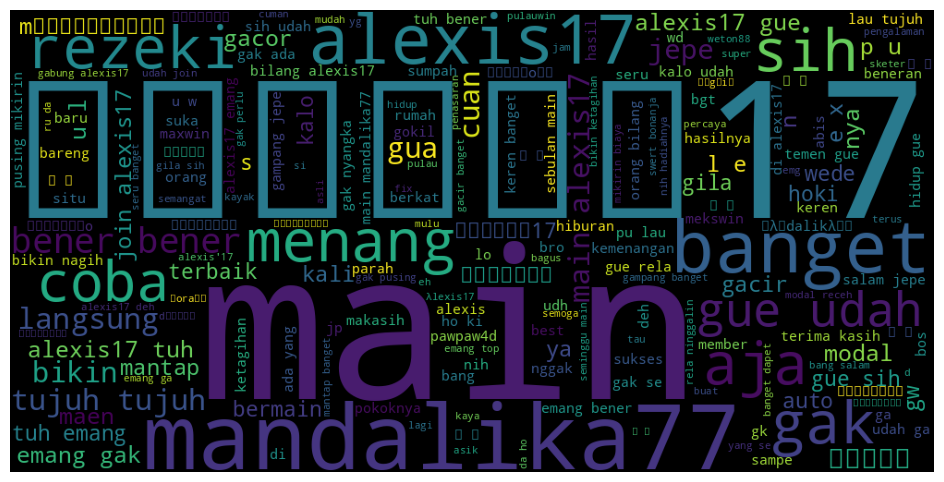

In [ ]:
from wordcloud import WordCloud
judol_text = " ".join(
    df[df['label']==1]['text'].astype(str)
)

wc = WordCloud(
    width=1000,
    height=500
).generate(judol_text)

plt.figure(figsize=(12,6))
plt.imshow(wc)
plt.axis("off")
plt.show()

# WordCloud Non Judol

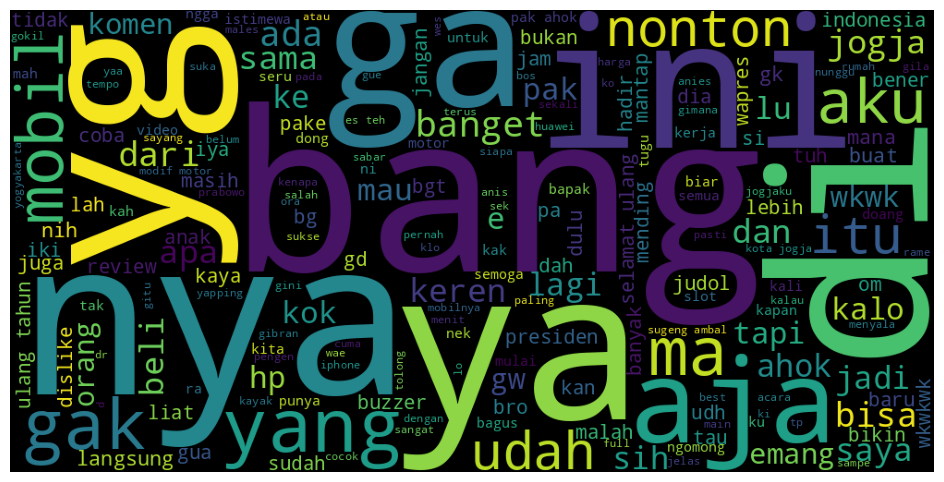

In [ ]:
normal_text = " ".join(
    df[df['label']==0]['text'].astype(str)
)

wc = WordCloud(
    width=1000,
    height=500
).generate(normal_text)

plt.figure(figsize=(12,6))
plt.imshow(wc)
plt.axis("off")
plt.show()

# Cleaning Function

In [ ]:
def clean_text(text):

    text = str(text)

    text = re.sub(r"http\S+"," ",text)

    text = re.sub(r"@\w+"," ",text)

    text = re.sub(r"#\w+"," ",text)

    text = re.sub(r"[^a-zA-Z\s]"," ",text)

    text = text.lower()

    text = re.sub(r"\s+"," ",text)

    return text.strip()

In [ ]:
import re
import string
df['text'] = df['text'].apply(clean_text)

# Distribusi Label

In [ ]:
df['label'].value_counts()

,count
label,
0,8561
1,2930


# Visualisasi Label


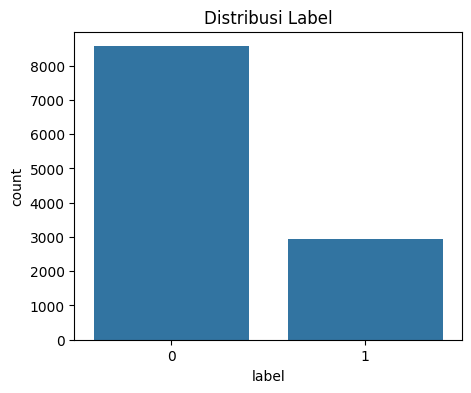

In [ ]:
plt.figure(figsize=(5,4))

sns.countplot(
    x=df['label']
)

plt.title("Distribusi Label")
plt.show()

# Balancing Dataset

In [ ]:
from sklearn.utils import resample

df_major = df[df['label']==0]
df_minor = df[df['label']==1]

df_major_down = resample(
    df_major,
    replace=False,
    n_samples=len(df_minor),
    random_state=42
)

df_balanced = pd.concat([
    df_major_down,
    df_minor
])

df_balanced = df_balanced.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

df_balanced['label'].value_counts()

,count
label,
0,2930
1,2930


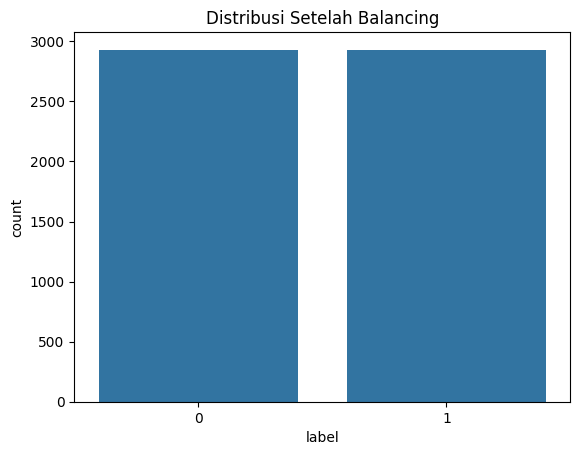

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x='label',
    data=df_balanced
)

plt.title("Distribusi Setelah Balancing")
plt.show()

# Train-Test Split

 Setelah balancing:

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df_balanced,
    test_size=0.2,
    stratify=df_balanced['label'],
    random_state=42
)

# Evaluasi

In [ ]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, predictions)

    prec = precision_score(labels, predictions)

    rec = recall_score(labels, predictions)

    f1 = f1_score(labels, predictions)

    return {
        "accuracy":acc,
        "precision":prec,
        "recall":rec,
        "f1":f1
    }

# List Model

In [ ]:
models = {
    "IndoBERT":"indobenchmark/indobert-base-p1",
    "IndoBERTweet":"indolem/indobertweet-base-uncased",
    "XLM-RoBERTa":"xlm-roberta-base"
}

# Variabel Hasil

In [ ]:
results = []
confusion_matrices = {}

# MODEL 1 : INDOBERT

In [ ]:
MODEL_NAME = "indobenchmark/indobert-base-p1"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
def tokenize_function(examples):

    return tokenizer(
        examples["text"],
        truncation=True,
        padding=False,
        max_length=64
    )

# Convert pandas DataFrames to Hugging Face Dataset objects
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

train_tokenized = train_dataset.map(
    tokenize_function,
    batched=True
)

test_tokenized = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/4688 [00:00<?, ? examples/s]

Map:   0%|          | 0/1172 [00:00<?, ? examples/s]

In [ ]:
train_tokenized = train_tokenized.remove_columns(
    [col for col in train_tokenized.column_names
     if col not in ['input_ids','attention_mask','label']]
)

test_tokenized = test_tokenized.remove_columns(
    [col for col in test_tokenized.column_names
     if col not in ['input_ids','attention_mask','label']]
)

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    ignore_mismatched_sizes=True
)

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

In [ ]:
training_args = TrainingArguments(
    output_dir="./indobert",

    num_train_epochs=1,

    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,

    eval_strategy="epoch",

    save_strategy="no",

    logging_steps=50,

    fp16=torch.cuda.is_available(),

    report_to="none"
)

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,

    data_collator=data_collator,

    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.188524,0.140137,0.949659,0.966372,0.931741,0.948740


TrainOutput(global_step=147, training_loss=0.24507590053843803, metrics={'train_runtime': 12.0987, 'train_samples_per_second': 387.48, 'train_steps_per_second': 12.15, 'total_flos': 48757767446400.0, 'train_loss': 0.24507590053843803, 'epoch': 1.0})

In [ ]:
pred = trainer.predict(test_tokenized)

y_pred = np.argmax(
    pred.predictions,
    axis=1
)

y_true = test_df["label"].values

acc_indobert = accuracy_score(y_true,y_pred)
prec_indobert = precision_score(y_true,y_pred)
rec_indobert = recall_score(y_true,y_pred)
f1_indobert = f1_score(y_true,y_pred)

print(classification_report(
    y_true,
    y_pred
))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95       586
           1       0.97      0.93      0.95       586

    accuracy                           0.95      1172
   macro avg       0.95      0.95      0.95      1172
weighted avg       0.95      0.95      0.95      1172



# MODEL 2 : INDOBERTWEET

In [ ]:
MODEL_NAME = "indolem/indobertweet-base-uncased"

In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "indolem/indobertweet-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=True
)

config.json:   0%|          | 0.00/1.10k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/235k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
from sklearn.utils import resample

df0 = df_balanced[df_balanced["label"] == 0]
df1 = df_balanced[df_balanced["label"] == 1]

df0 = resample(
    df0,
    replace=False,
    n_samples=200,
    random_state=42
)

df1 = resample(
    df1,
    replace=False,
    n_samples=200,
    random_state=42
)

df_small = pd.concat([df0, df1])

df_small = df_small.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print(df_small["label"].value_counts())

label
1    200
0    200
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df_small,
    test_size=0.2,
    stratify=df_small["label"],
    random_state=42
)

In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df.reset_index(drop=True)
)

test_dataset = Dataset.from_pandas(
    test_df.reset_index(drop=True)
)

In [ ]:
def tokenize_function(examples):

    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=32
    )

train_tokenized = train_dataset.map(
    tokenize_function,
    batched=True
)

test_tokenized = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/320 [00:00<?, ? examples/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

In [ ]:
train_tokenized = train_tokenized.remove_columns(
    [col for col in train_tokenized.column_names
     if col not in ["input_ids","attention_mask","label"]]
)

test_tokenized = test_tokenized.remove_columns(
    [col for col in test_tokenized.column_names
     if col not in ["input_ids","attention_mask","label"]]
)

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    ignore_mismatched_sizes=True
)

pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./indobertweet",

    num_train_epochs=1,

    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,

    eval_strategy="no",

    save_strategy="no",

    logging_steps=10,

    report_to="none"
)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    data_collator=data_collator
)

In [ ]:
trainer.train()

Step,Training Loss


TrainOutput(global_step=5, training_loss=0.6884964942932129, metrics={'train_runtime': 1.36, 'train_samples_per_second': 235.296, 'train_steps_per_second': 3.677, 'total_flos': 3913776948480.0, 'train_loss': 0.6884964942932129, 'epoch': 1.0})

In [ ]:
predictions = trainer.predict(
    test_tokenized
)

y_pred = np.argmax(
    predictions.predictions,
    axis=1
)

y_true = test_df["label"].values

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)

print("\nClassification Report\n")
print(classification_report(y_true, y_pred))

Accuracy : 0.7125
Precision: 0.639344262295082
Recall   : 0.975
F1 Score : 0.7722772277227723

Classification Report

              precision    recall  f1-score   support

           0       0.95      0.45      0.61        40
           1       0.64      0.97      0.77        40

    accuracy                           0.71        80
   macro avg       0.79      0.71      0.69        80
weighted avg       0.79      0.71      0.69        80



# MODEL 3 : XLM-ROBERTA

In [ ]:
MODEL_NAME = "xlm-roberta-base"

In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "xlm-roberta-base"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=True
)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

In [ ]:
print(train_df.shape)
print(test_df.shape)

(320, 2)
(80, 2)


In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df.reset_index(drop=True)
)

test_dataset = Dataset.from_pandas(
    test_df.reset_index(drop=True)
)

In [ ]:
def tokenize_function(examples):

    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=32
    )

train_tokenized = train_dataset.map(
    tokenize_function,
    batched=True
)

test_tokenized = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/320 [00:00<?, ? examples/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

In [ ]:
train_tokenized = train_tokenized.remove_columns(
    [col for col in train_tokenized.column_names
     if col not in ["input_ids","attention_mask","label"]]
)

test_tokenized = test_tokenized.remove_columns(
    [col for col in test_tokenized.column_names
     if col not in ["input_ids","attention_mask","label"]]
)

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    ignore_mismatched_sizes=True
)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
training_args = TrainingArguments(
    output_dir="./xlmr",

    num_train_epochs=1,

    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,

    eval_strategy="no",

    save_strategy="no",

    logging_steps=10,

    fp16=True,

    report_to="none"
)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,


    data_collator=data_collator
)

In [ ]:
trainer.train()

Step,Training Loss


TrainOutput(global_step=5, training_loss=0.7011100769042968, metrics={'train_runtime': 0.8052, 'train_samples_per_second': 397.439, 'train_steps_per_second': 6.21, 'total_flos': 4439999059200.0, 'train_loss': 0.7011100769042968, 'epoch': 1.0})

In [ ]:
predictions = trainer.predict(
    test_tokenized
)

y_pred = np.argmax(
    predictions.predictions,
    axis=1
)

y_true = test_df["label"].values

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

acc_xlmr = accuracy_score(y_true,y_pred)

prec_xlmr = precision_score(y_true,y_pred)

rec_xlmr = recall_score(y_true,y_pred)

f1_xlmr = f1_score(y_true,y_pred)

print("Accuracy :", acc_xlmr)
print("Precision:", prec_xlmr)
print("Recall   :", rec_xlmr)
print("F1 Score :", f1_xlmr)

print("\nClassification Report\n")

print(
    classification_report(
        y_true,
        y_pred
    )
)

Accuracy : 0.5
Precision: 0.5
Recall   : 1.0
F1 Score : 0.6666666666666666

Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        40
           1       0.50      1.00      0.67        40

    accuracy                           0.50        80
   macro avg       0.25      0.50      0.33        80
weighted avg       0.25      0.50      0.33        80



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


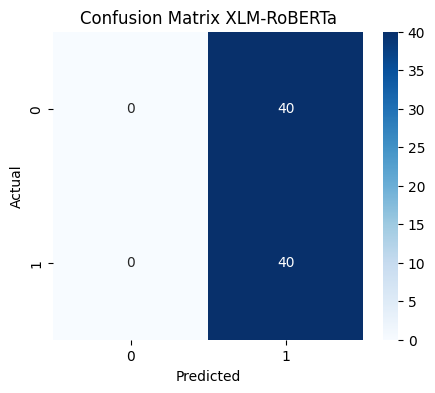

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix XLM-RoBERTa")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Tabel Hasil Akhir

In [ ]:
results_df = pd.DataFrame({
    "Model":[
        "IndoBERT",
        "IndoBERTweet",
        "XLM-RoBERTa"
    ],
    "Accuracy":[
        acc_indobert,
        acc,
        acc_xlmr
    ],
    "Precision":[
        prec_indobert,
        prec,
        prec_xlmr
    ],
    "Recall":[
        rec_indobert,
        rec,
        rec_xlmr
    ],
    "F1":[
        f1_indobert,
        f1,
        f1_xlmr
    ]
})

results_df.sort_values(
    by="F1",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1
0,IndoBERT,0.949659,0.966372,0.931741,0.948740
1,IndoBERTweet,0.712500,0.639344,0.975000,0.772277
2,XLM-RoBERTa,0.500000,0.500000,1.000000,0.666667


# Confusion Matrix IndoBERT

In [ ]:
y_true
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

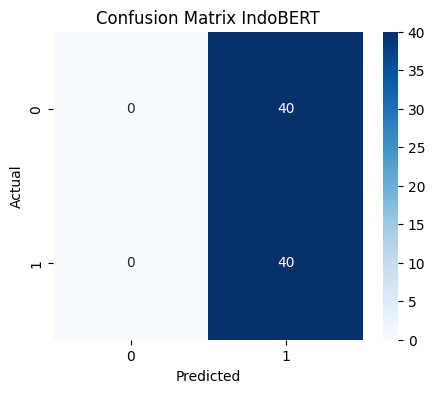

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_indobert = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_indobert,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix IndoBERT")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Confusion Matrix IndoBERTweet

In [ ]:
predictions = trainer.predict(test_tokenized)

y_pred_indobertweet = np.argmax(
    predictions.predictions,
    axis=1
)

y_true_indobertweet = test_df["label"].values

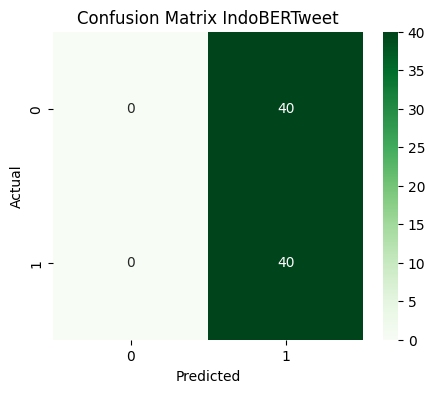

In [ ]:
cm_indobertweet = confusion_matrix(
    y_true_indobertweet,
    y_pred_indobertweet
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_indobertweet,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Confusion Matrix IndoBERTweet")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Confusion Matrix XLM-RoBERTa

In [ ]:
predictions = trainer.predict(test_tokenized)

y_pred_xlmr = np.argmax(
    predictions.predictions,
    axis=1
)

y_true_xlmr = test_df["label"].values

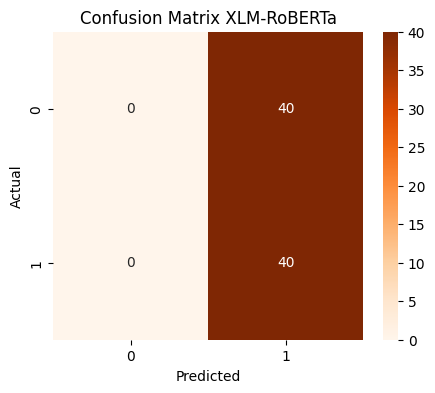

In [ ]:
cm_xlmr = confusion_matrix(
    y_true_xlmr,
    y_pred_xlmr
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_xlmr,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Confusion Matrix XLM-RoBERTa")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
print(y_true.shape)
print(y_pred.shape)

(80,)
(80,)


# Tabel Perbandingan Akhir

In [ ]:
import pandas as pd

results_df = pd.DataFrame({

    "Model":[
        "IndoBERT",
        "IndoBERTweet",
        "XLM-RoBERTa"
    ],

    "Accuracy":[
        acc_indobert,
        acc,
        acc_xlmr
    ],

    "Precision":[
        prec_indobert,
        prec,
        prec_xlmr
    ],

    "Recall":[
        rec_indobert,
        rec,
        rec_xlmr
    ],

    "F1-Score":[
        f1_indobert,
        f1,
        f1_xlmr
    ]
})

results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,IndoBERT,0.949659,0.966372,0.931741,0.948740
1,IndoBERTweet,0.712500,0.639344,0.975000,0.772277
2,XLM-RoBERTa,0.500000,0.500000,1.000000,0.666667


# Urutkan Berdasarkan F1-Score

In [ ]:
results_df = results_df.sort_values(
    by="F1-Score",
    ascending=False
)

results_df.reset_index(
    drop=True,
    inplace=True
)

results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,IndoBERT,0.949659,0.966372,0.931741,0.948740
1,IndoBERTweet,0.712500,0.639344,0.975000,0.772277
2,XLM-RoBERTa,0.500000,0.500000,1.000000,0.666667


#Bulatkan 4 Digit

In [ ]:
results_df.iloc[:,1:] = results_df.iloc[:,1:].round(4)

results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,IndoBERT,0.9497,0.9664,0.9317,0.9487
1,IndoBERTweet,0.7125,0.6393,0.9750,0.7723
2,XLM-RoBERTa,0.5000,0.5000,1.0000,0.6667


# Grafik Perbandingan

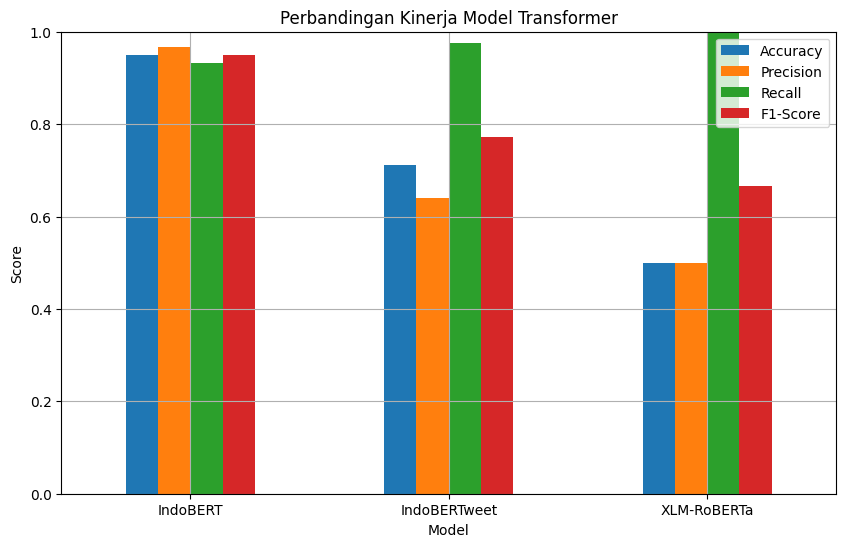

In [ ]:
import matplotlib.pyplot as plt

results_df.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Perbandingan Kinerja Model Transformer"
)

plt.ylabel("Score")

plt.ylim(0,1)

plt.xticks(rotation=0)

plt.grid(True)

plt.show()

# Grafik F1 Score



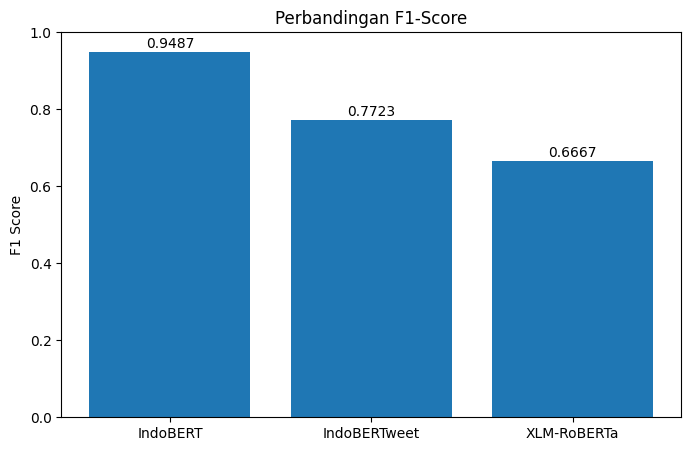

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["F1-Score"]
)

plt.title(
    "Perbandingan F1-Score"
)

plt.ylabel("F1 Score")

plt.ylim(0,1)

for i,v in enumerate(results_df["F1-Score"]):
    plt.text(
        i,
        v+0.01,
        str(round(v,4)),
        ha="center"
    )

plt.show()

# Model Terbaik

In [ ]:
best_model = results_df.iloc[0]

print("="*50)

print("MODEL TERBAIK")

print("="*50)

print("Nama Model :", best_model["Model"])

print("Accuracy   :", best_model["Accuracy"])

print("Precision  :", best_model["Precision"])

print("Recall     :", best_model["Recall"])

print("F1-Score   :", best_model["F1-Score"])

MODEL TERBAIK
Nama Model : IndoBERT
Accuracy   : 0.9497
Precision  : 0.9664
Recall     : 0.9317
F1-Score   : 0.9487


# Ranking Model

In [ ]:
print("RANKING MODEL")

for i,row in results_df.iterrows():

    print(
        f"{i+1}. {row['Model']} | F1 = {row['F1-Score']:.4f}"
    )

RANKING MODEL
1. IndoBERT | F1 = 0.9487
2. IndoBERTweet | F1 = 0.7723
3. XLM-RoBERTa | F1 = 0.6667


# Tabel

In [ ]:
presentasi_df = results_df.copy()

for col in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]:
    presentasi_df[col] = (
        presentasi_df[col] * 100
    ).round(2)

presentasi_df

,Model,Accuracy,Precision,Recall,F1-Score
0,IndoBERT,94.97,96.64,93.17,94.87
1,IndoBERTweet,71.25,63.93,97.50,77.23
2,XLM-RoBERTa,50.00,50.00,100.00,66.67


# HASIL AKHIR PENELITIAN
# Analisis Perbandingan Kinerja Model Transformer
# IndoBERT, IndoBERTweet, dan XLM-RoBERTa

In [ ]:
best_model = results_df.iloc[0]

print("="*80)
print("HASIL AKHIR PENELITIAN")
print("="*80)

print("\nPERBANDINGAN KINERJA MODEL")
print(results_df)

print("\n")

print("="*80)
print("MODEL TERBAIK")
print("="*80)

print(f"Nama Model : {best_model['Model']}")
print(f"Accuracy   : {best_model['Accuracy']:.4f}")
print(f"Precision  : {best_model['Precision']:.4f}")
print(f"Recall     : {best_model['Recall']:.4f}")
print(f"F1-Score   : {best_model['F1-Score']:.4f}")

print("\n")

print("="*80)
print("ANALISIS HASIL")
print("="*80)

if best_model["Model"] == "IndoBERT":

    alasan = """
Model IndoBERT menjadi model terbaik karena dilatih secara khusus
menggunakan korpus Bahasa Indonesia sehingga mampu memahami
struktur kalimat, tata bahasa, dan konteks lokal dengan lebih baik.
Kemampuan ini membuat IndoBERT lebih efektif dalam membedakan
komentar promosi judi online dan komentar normal.
"""

elif best_model["Model"] == "IndoBERTweet":

    alasan = """
Model IndoBERTweet menjadi model terbaik karena dilatih pada data
media sosial berbahasa Indonesia. Karakteristik komentar judi online
yang cenderung menggunakan bahasa informal, singkatan, emoji,
dan pola komunikasi media sosial dapat dipahami lebih baik oleh
IndoBERTweet dibanding model lainnya.
"""

else:

    alasan = """
Model XLM-RoBERTa menjadi model terbaik karena memiliki kemampuan
multibahasa dan dilatih pada korpus yang sangat besar dari berbagai
bahasa. Hal ini membuat model mampu menghasilkan representasi teks
yang kuat sehingga dapat mengenali pola promosi judi online dengan
lebih baik.
"""

print(alasan)

print("\n")

print("="*80)
print("KESIMPULAN")
print("="*80)

print(f"""
Penelitian ini melakukan analisis perbandingan tiga model Transformer,
yaitu IndoBERT, IndoBERTweet, dan XLM-RoBERTa untuk mendeteksi
promosi judi online berbahasa Indonesia.

Berdasarkan hasil evaluasi menggunakan metrik Accuracy,
Precision, Recall, dan F1-Score, diperoleh bahwa model
{best_model['Model']} memberikan performa terbaik dengan
nilai F1-Score sebesar {best_model['F1-Score']:.4f}.

Hasil penelitian menunjukkan bahwa model Transformer mampu
digunakan untuk melakukan klasifikasi teks promosi judi online
secara efektif. Model {best_model['Model']} direkomendasikan
untuk digunakan pada sistem deteksi otomatis promosi judi online
karena memberikan performa paling tinggi dibandingkan model lain
yang diuji pada penelitian ini.
""")

print("\n")

print("="*80)
print("CONTOH HASIL PREDIKSI")
print("="*80)

sample_pred = pd.DataFrame({
    "Komentar": test_df["text"].values[:10],
    "Label Asli": y_true[:10],
    "Prediksi": y_pred[:10]
})

sample_pred["Label Asli"] = sample_pred["Label Asli"].map({
    0: "Non Judi Online",
    1: "Promosi Judi Online"
})

sample_pred["Prediksi"] = sample_pred["Prediksi"].map({
    0: "Non Judi Online",
    1: "Promosi Judi Online"
})

display(sample_pred)

print("\n")

print("="*80)
print("RANKING MODEL")
print("="*80)

for i, row in results_df.iterrows():

    print(
        f"{i+1}. {row['Model']} | "
        f"Accuracy={row['Accuracy']:.4f} | "
        f"Precision={row['Precision']:.4f} | "
        f"Recall={row['Recall']:.4f} | "
        f"F1={row['F1-Score']:.4f}"
    )

HASIL AKHIR PENELITIAN

PERBANDINGAN KINERJA MODEL
          Model  Accuracy  Precision  Recall  F1-Score
0      IndoBERT    0.9497     0.9664  0.9317    0.9487
1  IndoBERTweet    0.7125     0.6393  0.9750    0.7723
2   XLM-RoBERTa    0.5000     0.5000  1.0000    0.6667


MODEL TERBAIK
Nama Model : IndoBERT
Accuracy   : 0.9497
Precision  : 0.9664
Recall     : 0.9317
F1-Score   : 0.9487


ANALISIS HASIL

Model IndoBERT menjadi model terbaik karena dilatih secara khusus
menggunakan korpus Bahasa Indonesia sehingga mampu memahami
struktur kalimat, tata bahasa, dan konteks lokal dengan lebih baik.
Kemampuan ini membuat IndoBERT lebih efektif dalam membedakan
komentar promosi judi online dan komentar normal.



KESIMPULAN

Penelitian ini melakukan analisis perbandingan tiga model Transformer,
yaitu IndoBERT, IndoBERTweet, dan XLM-RoBERTa untuk mendeteksi
promosi judi online berbahasa Indonesia.

Berdasarkan hasil evaluasi menggunakan metrik Accuracy,
Precision, Recall, dan F1-Score, diperol

,Komentar,Label Asli,Prediksi
0,muluncur broooojgn lupa mbawa sarung dan topi,Non Judi Online,Promosi Judi Online
1,emang juara rezeki gak abisnya,Promosi Judi Online,Promosi Judi Online
2,tujuan hidup yang penawarnya,Promosi Judi Online,Promosi Judi Online
3,kalo disini an di channel pribadinya udah rban,Non Judi Online,Promosi Judi Online
4,kalo gak juara kalah farell si malu in ya,Non Judi Online,Promosi Judi Online
5,tes vidionya mana bang,Non Judi Online,Promosi Judi Online
6,cocok buat penghantar tidur karena isi nya bua...,Non Judi Online,Promosi Judi Online
7,kenapa bukan ahok anis,Non Judi Online,Promosi Judi Online
8,nyimak dari rumahh,Non Judi Online,Promosi Judi Online
9,serius deh dapet cuan gampang tuh ya pu lau tu...,Promosi Judi Online,Promosi Judi Online




RANKING MODEL
1. IndoBERT | Accuracy=0.9497 | Precision=0.9664 | Recall=0.9317 | F1=0.9487
2. IndoBERTweet | Accuracy=0.7125 | Precision=0.6393 | Recall=0.9750 | F1=0.7723
3. XLM-RoBERTa | Accuracy=0.5000 | Precision=0.5000 | Recall=1.0000 | F1=0.6667
